In [12]:
import cogent3
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import seaborn as sns
import paths
import pandas as pd
import numpy as np


import pickle

import re
import trinuc_models as trinucs # this module must be in the same directory as this notebook

In [2]:
#function to parse the alignment lenght

def parse_alignment_length(s: str, fmt: str = "{:.6e}") -> str:
    """
    Parse strings like "alignment length: X" and return X formatted in scientific notation.

    Parameters
    - s: input string containing a token like "alignment length: 12345"
    - fmt: a format string compatible with float.format, default "{:.6e}" (6 decimals in exp notation)

    Returns
    - str: the parsed number formatted according to `fmt` (scientific notation by default)

    Raises ValueError if the token is not found.
    """
    m = re.search(r'alignment\s*length\s*:\s*([0-9]+(?:\.[0-9]+)?)', s, re.I)
    if not m:
        raise ValueError(f"Can't parse alignment length from: {s!r}")
    token = m.group(1)
    # normalize to float for consistent formatting
    value = float(token)
    return fmt.format(value)

In [3]:
# Creates a trinucleotide alphabet
aln = cogent3.get_dataset("primate-brca1")
aln = aln.take_seqs(["Human", "Chimpanzee", "Rhesus"])
aln = aln.omit_gap_pos(allowed_gap_frac=0, motif_length=3)
alphabet_trinucs = aln.moltype.alphabet.get_kmer_alphabet(3)

## Intergenic Ancestral Repeats (IGAR)

In [4]:
region = "intergenicAR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

IGAR_motif_probs = result_IGAR.lf.get_param_value("mprobs")
humanQ_IGAR = result_IGAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_IGAR = expected_number_subs(IGAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS IGAR: ")
print(humanENS_IGAR)

result_IGAR.lf

alignment lenght  2.418960e+05
Human ENS IGAR: 
1.2738177508410229


GT_CpG_ss
log-likelihood = -959105.8785
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        1.85              10.11    1.02    0.66    1.15
Human         root        1.27              12.33    0.82    0.49    0.77
Orangutan     root        3.17              10.78    1.05    0.85    1.04
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.68    0.70    0.83    0.84    0.69    0.47    1.04    0.81
0.57    0.48    0.59    0.71    0.55    0.42    0.48    0.54
0.67    1.09    0.97    0.92    1.00    0.77    1.04    1.06
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.03    0.01    0.02    0.02    0.02    0.02    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.02    0.02    0.01    0.01    0.02    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.02    0.01    0.02    0.00    0.00    0.00    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.02    0.03
----------------------------

## CDS

In [25]:
region = "cds/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_cds=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

cds_motif_probs = result_cds.lf.get_param_value("mprobs")
humanQ_cds = result_cds.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_cds = expected_number_subs(cds_motif_probs, humanQ_cds, t=1.0)

print("Human ENS cds: ")
print(humanENS_cds)

#calculate cds if using IGARQ ENS
mprobs = result_cds.lf.get_motif_probs().to_dict()
# get codon freqs and normalize for inclusion of stop codons at 1e-12
mle_freqs = {alphabet_trinuc: mprobs.get(alphabet_trinuc, 1e-12) / (1+3e-12) for alphabet_trinuc in alphabet_trinucs}
mle_freqs = np.array(list(mle_freqs.values()))

humanENS_cds_IGARQ = expected_number_subs(mle_freqs, humanQ_IGAR, t=1.0)

print("Human ENS cds with IGAR Q: ")
print(humanENS_cds_IGARQ)

result_cds.lf

alignment lenght  5.387610e+05
Human ENS cds: 
0.012327805922017508
Human ENS cds with IGAR Q: 
1.2963924710026244


GNC_CpG_ss
log-likelihood = -797974.7978
number of free parameters = 42
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        0.02               3.58    1.13    1.85    0.93
Orangutan     root        0.05               4.25    1.09    4.05    0.52
Human         root        0.01               4.16    1.09    4.06    0.68
-------------------------------------------------------------------------

continued: 
=====================================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C    omega
---------------------------------------------------------------------
0.82    1.14    1.86    1.62    1.48    1.01    0.76    1.89     0.50
0.70    1.19    2.64    2.27    1.16    0.76    0.63    4.39     0.24
1.20    1.39    4.56    3.79    1.30    1.20    0.68    2.69     0.33
---------------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.01    0.02    0.04    0.01    0.01    0.02    0.01    0.01    0.01    0.03
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.01    0.01    0.00    0.02    0.02    0.01    0.01    0.02    0.04    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.01    0.03    0.01    0.02    0.01    0.02    0.02    0.00    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.05    0.01    0.02    0.03    0.05    0.02    0.01    0.04    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAC     TAT
----------------------------------------------------------------------------
0.01    0.03    0.02    0.01    0.00    0.02    0.03    0.01    0.02    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TCA     TCC     TCG     TCT     TGC     TGG     TGT     TTA     TTC     TTG
----------------------------------------------------------------------------
0.01    0.02    0.01    0.01    0.01    0.01    0.01    0.00    0.02    0.01
----------------------------------------------------------------------------

continued: 
====
 TTT
----
0.01
----

## Introns (nonUTR)

In [26]:
region = "introns_nonUTR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_introns=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_introns.lf.get_param_value("mprobs")
humanQ_introns = result_introns.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_introns = expected_number_subs(intron_motif_probs, humanQ_introns, t=1.0)
#This is the ENS of introns if selection was the same as on IGAR. Instead of using the introns Q matrix humanQ_introns, I use the IGAR Q humanQ_IGAR
humanENS_introns_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS introns: ")
print(humanENS_introns)
print("Human ENS introns with IGAR Q: ")
print(humanENS_introns_IGARQ)

result_introns.lf

alignment lenght  2.513400e+04
Human ENS introns: 
0.6123211021413366
Human ENS introns with IGAR Q: 
1.2751701036078402


GT_CpG_ss
log-likelihood = -88779.1563
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.61              11.77    0.97    0.90    0.62
Chimpanzee    root        0.59              12.69    1.28    1.17    1.07
Orangutan     root        2.49              11.23    0.97    1.04    1.13
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.62    0.63    0.53    0.53    0.84    0.57    0.73    0.74
0.88    0.93    0.76    0.67    0.98    0.66    1.19    1.17
0.66    0.96    0.81    0.73    0.92    0.70    1.16    1.08
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.02    0.01    0.01    0.02    0.03    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.03    0.01    0.03    0.00    0.00    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.03    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.02
----------------------------

## 5' UTR

In [27]:
region = "introns5UTR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_5UTR=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_5UTR.lf.get_param_value("mprobs")
humanQ_5UTR = result_5UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_5UTR = expected_number_subs(intron_motif_probs, humanQ_5UTR, t=1.0)
#This is the ENS of 5UTR if selection was the same as on IGAR. Instead of using the 5UTR Q matrix humanQ_5UTR, I use the IGAR Q humanQ_IGAR
humanENS_5UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 5UTR: ")
print(humanENS_5UTR)
print("Human ENS 5UTR with IGAR Q: ")
print(humanENS_5UTR_IGARQ)

result_5UTR.lf

alignment lenght  1.034100e+04
Human ENS 5UTR: 
0.24796535026671263
Human ENS 5UTR with IGAR Q: 
1.2821033943314077


GT_CpG_ss
log-likelihood = -30180.8640
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.25               8.89    0.80    0.91    1.19
Chimpanzee    root        0.33               7.19    0.84    0.66    0.38
Orangutan     root        1.11               8.89    0.87    1.02    0.46
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
1.01    1.23    0.66    1.02    1.17    0.65    1.18    1.17
0.57    1.01    0.82    0.67    0.98    0.77    0.49    0.82
0.76    1.25    0.61    0.73    1.22    0.93    0.57    1.07
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.02    0.02    0.04    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.03    0.01    0.02    0.00    0.01    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.03    0.03    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.01    0.02    0.00    0.02    0.01    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.02
----------------------------

## 3' UTR

In [28]:
region = "introns3UTR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_3UTR=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_3UTR.lf.get_param_value("mprobs")
humanQ_3UTR = result_3UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_3UTR = expected_number_subs(intron_motif_probs, humanQ_3UTR, t=1.0)
#This is the ENS of 3UTR if selection was the same as on IGAR. Instead of using the 3UTR Q matrix humanQ_3UTR, I use the IGAR Q humanQ_IGAR
humanENS_3UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 3UTR: ")
print(humanENS_3UTR)
print("Human ENS 3UTR with IGAR Q: ")
print(humanENS_3UTR_IGARQ)

result_3UTR.lf

alignment lenght  3.063000e+03
Human ENS 3UTR: 
1.2625403239886714
Human ENS 3UTR with IGAR Q: 
1.278065732293793


GT_CpG_ss
log-likelihood = -11766.6548
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        1.25              18.17    0.75    0.73    0.62
Chimpanzee    root        1.92               7.90    0.94    1.25    1.27
Orangutan     root        1.70              20.43    0.87    1.11    0.55
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.37    0.95    0.51    0.37    1.30    0.51    0.56    1.00
0.57    1.37    0.92    1.21    1.08    0.40    1.54    1.04
0.68    1.03    0.45    0.51    1.18    0.97    0.66    0.66
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.02    0.01    0.01    0.02    0.01    0.01    0.02    0.04    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.03    0.02    0.00    0.02    0.00    0.01    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.04    0.02    0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.01    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.01    0.01    0.02
----------------------------

## Introns Ancestral Repeats (IntronAR)

In [29]:
region = "intronsAR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_intronsAR=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intronsAR_motif_probs = result_intronsAR.lf.get_param_value("mprobs")
humanQ_intronsAR = result_intronsAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_intronsAR = expected_number_subs(intronsAR_motif_probs, humanQ_intronsAR, t=1.0)
#This is the ENS of intronsAR if selection was the same as on IGAR. Instead of using the intronsAR Q matrix humanQ_intronsAR, I use the IGAR Q humanQ_IGAR
humanENS_intronsAR_IGARQ = expected_number_subs(intronsAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS intronsAR: ")
print(humanENS_intronsAR)
print("Human ENS intronsAR with IGAR Q: ")
print(humanENS_intronsAR_IGARQ)

#print("Motif probs: ")
#print(intronsAR_motif_probs)

result_intronsAR.lf

alignment lenght  1.775160e+05
Human ENS intronsAR: 
1.0670720071708244
Human ENS intronsAR with IGAR Q: 
1.2893261219373546


GT_CpG_ss
log-likelihood = -673472.6145
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        1.06               8.43    1.00    0.80    0.67
Orangutan     root        2.94               7.92    0.94    0.98    1.25
Chimpanzee    root        0.86               7.64    0.86    0.90    1.01
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.58    0.87    0.40    0.43    0.77    0.48    0.73    0.81
0.80    1.02    0.85    0.80    1.03    0.68    1.05    1.15
0.65    0.82    0.72    0.77    0.77    0.47    0.88    0.93
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.01    0.00    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.02    0.02    0.03    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.02    0.01    0.02    0.00    0.01    0.01    0.01    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.02    0.01    0.02    0.02    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.02    0.02    0.02    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.01    0.02    0.02
----------------------------

## Intergenic distal (5kb distal from transcript)

In [30]:
region = "distalIG/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_distalIG=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

distalIG_motif_probs = result_distalIG.lf.get_param_value("mprobs")
humanQ_distalIG = result_distalIG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_distalIG = expected_number_subs(distalIG_motif_probs, humanQ_distalIG, t=1.0)
humanENS_distalIG_IGARQ = expected_number_subs(distalIG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS distalIG: ")
print(humanENS_distalIG)
print("Human ENS distalIG with IGAR Q: ")
print(humanENS_distalIG_IGARQ)

result_distalIG.lf

alignment lenght  4.965600e+04
Human ENS distalIG: 
1.057870161280981
Human ENS distalIG with IGAR Q: 
1.2780738214682255


GT_CpG_ss
log-likelihood = -180696.6308
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Orangutan     root        1.71              13.11    0.83    0.93    0.51
Human         root        1.05              12.46    0.74    1.18    0.48
Chimpanzee    root        0.93              13.44    0.99    0.88    0.69
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.57    0.71    0.49    0.57    0.81    0.45    0.50    0.85
0.55    0.63    0.56    0.58    0.71    0.73    0.79    0.86
0.56    0.91    0.51    0.53    0.88    0.64    0.88    0.86
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.02    0.01    0.01    0.02    0.04    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.03    0.03    0.01    0.02    0.00    0.00    0.01    0.01    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.03    0.01    0.02    0.03    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.03    0.03    0.02    0.01    0.01    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.01    0.01    0.01
----------------------------

## Intergenic proximal 5' (5kb proximal from transcript start)

In [31]:
region = "proximal5IG/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal5IG=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal5IG_motif_probs = result_proximal5IG.lf.get_param_value("mprobs")
humanQ_proximal5IG = result_proximal5IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal5IG = expected_number_subs(proximal5IG_motif_probs, humanQ_proximal5IG, t=1.0)
humanENS_proximal5IG_IGARQ = expected_number_subs(proximal5IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal5IG: ")
print(humanENS_proximal5IG)
print("Human ENS proximal5IG with IGAR Q: ")
print(humanENS_proximal5IG_IGARQ)

result_proximal5IG.lf

alignment lenght  3.696600e+04
Human ENS proximal5IG: 
0.8302302326166922
Human ENS proximal5IG with IGAR Q: 
1.2770178413049624


GT_CpG_ss
log-likelihood = -126643.0901
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Human         root        0.82              14.15    0.98    1.02    0.44
Chimpanzee    root        0.36              24.72    1.18    2.05    1.15
Orangutan     root        2.02               9.89    0.98    1.09    0.73
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.43    0.89    0.48    0.42    0.89    0.45    0.35    0.89
0.82    0.65    0.39    0.46    0.89    0.98    0.86    1.40
0.57    0.99    0.69    0.71    1.04    0.54    0.63    1.03
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.01    0.01    0.02    0.01    0.01    0.01    0.01    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.01    0.01    0.01    0.01    0.01    0.01    0.02    0.04    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.02    0.04    0.01    0.03    0.00    0.00    0.01    0.00    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.01    0.01    0.03    0.01    0.02    0.03    0.00    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.02    0.03    0.04    0.02    0.01    0.02    0.02    0.01    0.01    0.00
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.02    0.02    0.00    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.01
----------------------------

## Intergenic proximal 3' (5kb proximal from transcript end)

In [32]:
region = "proximal3IG/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "trinuc_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal3IG=pickle.load(infile)

file_in = folder_in + "trinuc_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal3IG_motif_probs = result_proximal3IG.lf.get_param_value("mprobs")
humanQ_proximal3IG = result_proximal3IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal3IG = expected_number_subs(proximal3IG_motif_probs, humanQ_proximal3IG, t=1.0)
humanENS_proximal3IG_IGARQ = expected_number_subs(proximal3IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal3IG: ")
print(humanENS_proximal3IG)
print("Human ENS proximal3IG with IGAR Q: ")
print(humanENS_proximal3IG_IGARQ)

result_proximal3IG.lf

alignment lenght  1.816500e+04
Human ENS proximal3IG: 
0.8825496944067768
Human ENS proximal3IG with IGAR Q: 
1.2806066416272213


GT_CpG_ss
log-likelihood = -66538.1114
number of free parameters = 39
=====
omega
-----
 1.00
-----
=========================================================================
edge          parent    length    (CG>TG | CG>CA)     A>C     A>G     A>T
-------------------------------------------------------------------------
Chimpanzee    root        1.06              12.19    2.52    3.53    1.74
Human         root        0.88              17.29    1.66    1.24    0.42
Orangutan     root        1.93               8.05    1.34    1.74    0.94
-------------------------------------------------------------------------

continued: 
============================================================
 C>A     C>G     C>T     G>A     G>C     G>T     T>A     T>C
------------------------------------------------------------
0.76    1.92    1.11    1.56    1.50    1.20    2.13    1.98
0.44    0.96    0.30    0.51    0.35    0.78    0.27    0.80
1.01    1.38    0.85    0.80    1.33    1.39    1.37    1.30
------------------------------------------------------------

============================================================================
 AAA     AAC     AAG     AAT     ACA     ACC     ACG     ACT     AGA     AGC
----------------------------------------------------------------------------
0.02    0.01    0.02    0.01    0.02    0.02    0.01    0.01    0.02    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 AGG     AGT     ATA     ATC     ATG     ATT     CAA     CAC     CAG     CAT
----------------------------------------------------------------------------
0.03    0.02    0.01    0.01    0.01    0.01    0.01    0.02    0.03    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 CCA     CCC     CCG     CCT     CGA     CGC     CGG     CGT     CTA     CTC
----------------------------------------------------------------------------
0.03    0.03    0.01    0.03    0.00    0.01    0.01    0.01    0.01    0.02
----------------------------------------------------------------------------

continued: 
============================================================================
 CTG     CTT     GAA     GAC     GAG     GAT     GCA     GCC     GCG     GCT
----------------------------------------------------------------------------
0.03    0.02    0.02    0.01    0.03    0.01    0.01    0.03    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 GGA     GGC     GGG     GGT     GTA     GTC     GTG     GTT     TAA     TAC
----------------------------------------------------------------------------
0.03    0.02    0.03    0.01    0.01    0.02    0.02    0.01    0.01    0.01
----------------------------------------------------------------------------

continued: 
============================================================================
 TAG     TAT     TCA     TCC     TCG     TCT     TGA     TGC     TGG     TGT
----------------------------------------------------------------------------
0.01    0.01    0.01    0.02    0.00    0.02    0.02    0.02    0.03    0.02
----------------------------------------------------------------------------

continued: 
============================
 TTA     TTC     TTG     TTT
----------------------------
0.01    0.02    0.01    0.01
----------------------------

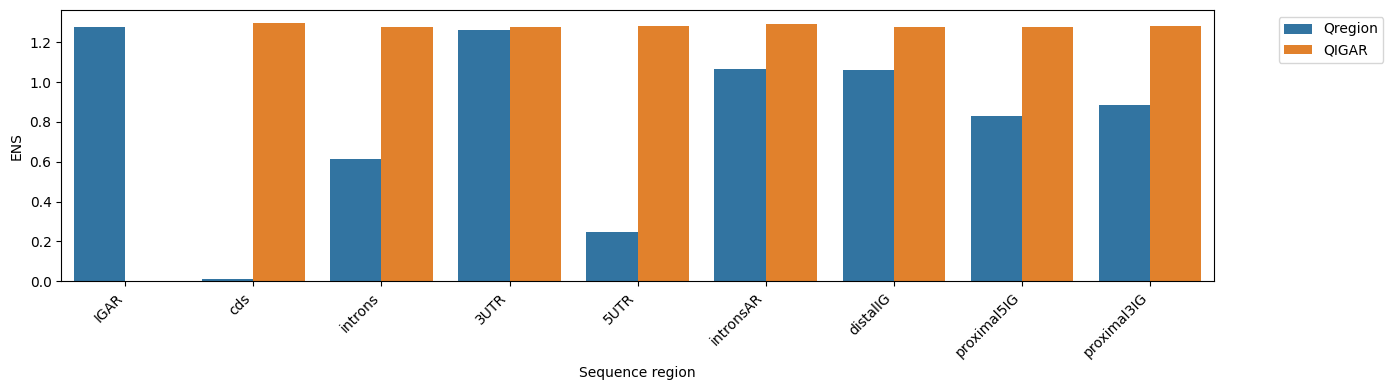

In [37]:
ENS_data = pd.DataFrame([
    ['IGAR', 'Qregion', humanENS_IGAR],
    ['cds', 'Qregion', humanENS_cds],
    ['introns', 'Qregion', humanENS_introns],
    ['3UTR', 'Qregion', humanENS_3UTR],
    ['5UTR', 'Qregion', humanENS_5UTR],
    ['intronsAR', 'Qregion', humanENS_intronsAR],
    ['distalIG', 'Qregion', humanENS_distalIG],
    ['proximal5IG', 'Qregion', humanENS_proximal5IG],
    ['proximal3IG', 'Qregion', humanENS_proximal3IG],
    ['cds', 'QIGAR', humanENS_cds_IGARQ],
    ['introns', 'QIGAR', humanENS_introns_IGARQ],
    ['3UTR', 'QIGAR', humanENS_3UTR_IGARQ],
    ['5UTR', 'QIGAR', humanENS_5UTR_IGARQ],
    ['intronsAR', 'QIGAR', humanENS_intronsAR_IGARQ],
    ['distalIG', 'QIGAR', humanENS_distalIG_IGARQ],
    ['proximal5IG', 'QIGAR', humanENS_proximal5IG_IGARQ],
    ['proximal3IG', 'QIGAR', humanENS_proximal3IG_IGARQ]
    ],
    columns = ['Sequence region', 'Q type', 'ENS'])

plt.figure(figsize=(14, 4))
ax = sns.barplot(
    data=ENS_data,
    x='Sequence region',
    y='ENS',
    hue='Q type'
)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

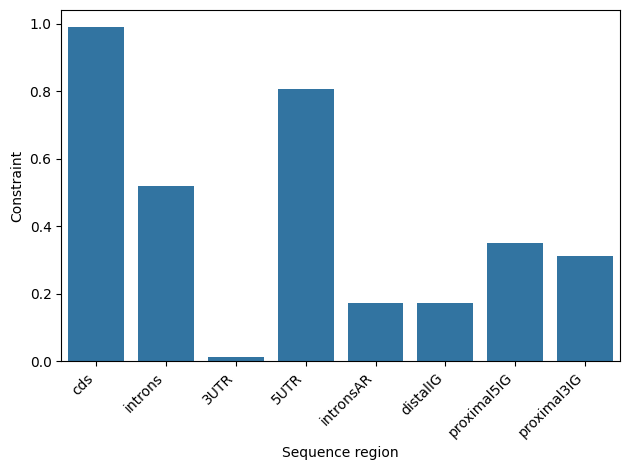

In [38]:
def calculate_constraint(ENS, ENSneutral):
    return (ENSneutral - ENS)/ENSneutral 

Constraint_data = pd.DataFrame([
    ['cds', calculate_constraint(humanENS_cds, humanENS_cds_IGARQ)],
    ['introns', calculate_constraint(humanENS_introns, humanENS_introns_IGARQ)],
    ['3UTR', calculate_constraint(humanENS_3UTR, humanENS_3UTR_IGARQ)],
    ['5UTR', calculate_constraint(humanENS_5UTR, humanENS_5UTR_IGARQ)],
    ['intronsAR', calculate_constraint(humanENS_intronsAR, humanENS_intronsAR_IGARQ)],
    ['distalIG', calculate_constraint(humanENS_distalIG, humanENS_distalIG_IGARQ)],
    ['proximal5IG', calculate_constraint(humanENS_proximal5IG, humanENS_proximal5IG_IGARQ)],
    ['proximal3IG', calculate_constraint(humanENS_proximal3IG, humanENS_proximal3IG_IGARQ)],
    ],
    columns = ['Sequence region', 'Constraint'])

ax = sns.barplot(
    data=Constraint_data,
    x='Sequence region',
    y='Constraint'
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
#Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

,Sequence region,Constraint
0,cds,0.990491
1,introns,0.519812
2,3UTR,0.012148
3,5UTR,0.806595
4,intronsAR,0.172380
5,distalIG,0.172293
6,proximal5IG,0.349868
7,proximal3IG,0.310835
